Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv("../data/student_data.csv")

# Basic info
print(data.shape)
data.head()

(800, 10)


,attendance,study_hours,assignments_avg,internal_marks,previous_gpa,absences,participation_score,internet_usage_hours,sleep_hours,risk_level
0,88,23,55.857994,47.017683,5.37,13,2,7,7,Medium
1,78,10,94.216088,62.716169,9.86,19,7,4,7,Low
2,64,10,58.022396,41.421529,7.19,14,2,5,4,Medium
3,92,19,67.708892,65.698065,4.81,15,4,6,6,Low
4,57,17,60.774067,45.528406,4.60,22,7,5,5,High


Check Risk Distribution

In [2]:
data["risk_level"].value_counts()

risk_level
High      308
Medium    282
Low       210
Name: count, dtype: int64

Visualization

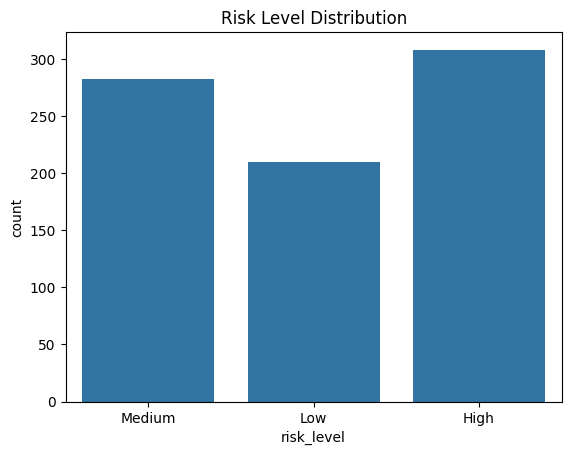

In [3]:
sns.countplot(x="risk_level", data=data)
plt.title("Risk Level Distribution")
plt.show()

Correlation Heatmap

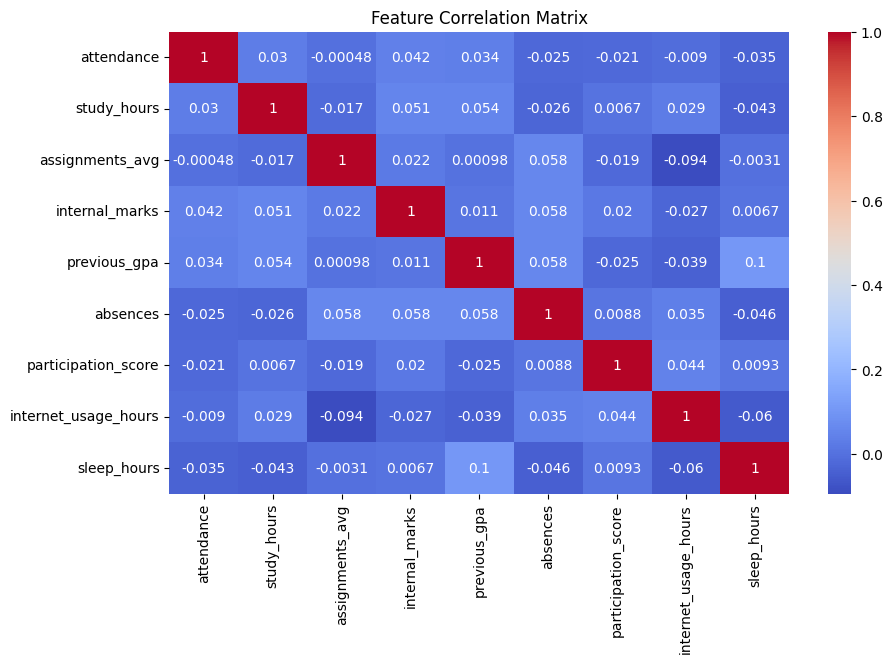

In [4]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

Model Training 

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Encode target variable
le = LabelEncoder()
data["risk_encoded"] = le.fit_transform(data["risk_level"])

# Features and target
X = data.drop(["risk_level", "risk_encoded"], axis=1)
y = data["risk_encoded"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.77      0.73        61
           1       0.68      0.78      0.73        41
           2       0.72      0.57      0.63        58

    accuracy                           0.70       160
   macro avg       0.70      0.71      0.70       160
weighted avg       0.70      0.70      0.70       160



c:\Users\DELL\Creative Cloud Files\Desktop\Adaptive_Learning_System\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


 Train Random Forest 

In [8]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)


rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.95

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.95      0.94        61
           1       0.95      0.88      0.91        41
           2       0.97      1.00      0.98        58

    accuracy                           0.95       160
   macro avg       0.95      0.94      0.95       160
weighted avg       0.95      0.95      0.95       160



Check Train Accuracy

In [9]:
print("Train Accuracy:", rf_model.score(X_train, y_train))
print("Test Accuracy:", rf_model.score(X_test, y_test))

Train Accuracy: 0.9984375
Test Accuracy: 0.95


Factors that most influence academic risk

In [10]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

internal_marks          0.357719
attendance              0.348607
study_hours             0.141501
previous_gpa            0.038635
assignments_avg         0.035159
absences                0.028157
internet_usage_hours    0.018270
participation_score     0.017717
sleep_hours             0.014234
dtype: float64


In [11]:
import pickle

with open("../models/risk_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Model saved successfully!")

Model saved successfully!
